In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso # Added Ridge and Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer # Added FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor # Added ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor # Added DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor # Added MLPRegressor
from xgboost import XGBRegressor # Added XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.decomposition import PCA

In [5]:
pd.set_option('display.max_columns', 100)

In [2]:
df = pd.read_csv('housing_data_after_feature_selection.csv')

In [6]:
df.head()

,Unnamed: 0,url,image_url,beds,baths,sqft,address,property_type,region,parking_total_spaces,walk_score,middle_school_distance,wind_risk,nearby_cities,zip_code,mobility_score,parking_quality_score,has_garage,county,price_volatility,price_reduction_total,price
0,0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"197 Lowell St, Arlington, MA 02474",single family,Arlington,4.0,81.0,0.4,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",2474,73.0,0.0,0,Middlesex,190775.778337,481500.0,999000
1,1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"225 Mystic St, Arlington, MA 02474",single family,Arlington,3.0,69.0,0.1,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",2474,65.0,1.0,0,Middlesex,75258.487893,189000.0,799000
2,2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"43 Longmeadow Rd, Arlington, MA 02474",single family,Arlington,5.0,32.0,0.2,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",2474,33.2,0.0,0,Middlesex,379500.000000,759000.0,899000
3,3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"11 Pine Ct, Arlington, MA 02476",single family,Arlington,2.0,84.0,0.7,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",2476,72.0,0.0,0,Middlesex,358034.448994,815000.0,998000
4,4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,"17 Norcross St FLOOR 3, Arlington, MA 02474",condo,Arlington,1.0,77.0,0.1,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",2474,84.6,1.0,0,Middlesex,16004.999219,-47000.0,668000


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7792 entries, 0 to 7791
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              7792 non-null   int64  
 1   url                     7792 non-null   object 
 2   image_url               7792 non-null   object 
 3   beds                    7792 non-null   float64
 4   baths                   7792 non-null   float64
 5   sqft                    7792 non-null   float64
 6   address                 7792 non-null   object 
 7   property_type           7792 non-null   object 
 8   region                  7792 non-null   object 
 9   parking_total_spaces    7792 non-null   float64
 10  walk_score              7792 non-null   float64
 11  middle_school_distance  7792 non-null   float64
 12  wind_risk               7792 non-null   float64
 13  nearby_cities           7792 non-null   object 
 14  zip_code                7792 non-null   

<Axes: ylabel='Density'>

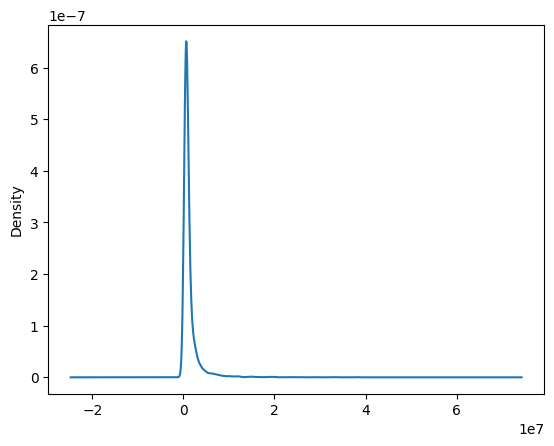

In [8]:
df['price'].plot(kind='kde')

In [16]:
X = df.drop(columns={'price','url','image_url','Unnamed: 0','address','nearby_cities',}) # dropping other cols which are of no use.

In [17]:
y = df['price']

<Axes: ylabel='Density'>

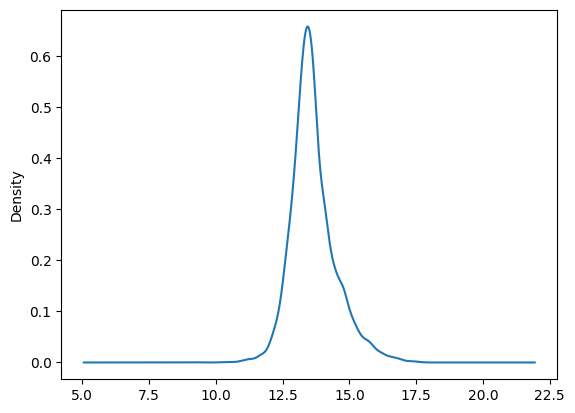

In [18]:
# applying log transformation to price col
np.log1p(y).plot(kind='kde')

In [19]:
y_transformed = np.log1p(y)

In [20]:
X

,beds,baths,sqft,property_type,region,parking_total_spaces,walk_score,middle_school_distance,wind_risk,zip_code,mobility_score,parking_quality_score,has_garage,county,price_volatility,price_reduction_total
0,3.0,2.0,1415.0,single family,Arlington,4.0,81.0,0.4,6.0,2474,73.0,0.0,0,Middlesex,190775.778337,481500.0
1,2.0,1.0,1064.0,single family,Arlington,3.0,69.0,0.1,6.0,2474,65.0,1.0,0,Middlesex,75258.487893,189000.0
2,2.0,1.0,1628.0,single family,Arlington,5.0,32.0,0.2,6.0,2474,33.2,0.0,0,Middlesex,379500.000000,759000.0
3,3.0,2.0,1824.0,single family,Arlington,2.0,84.0,0.7,6.0,2476,72.0,0.0,0,Middlesex,358034.448994,815000.0
4,2.0,2.0,1221.0,condo,Arlington,1.0,77.0,0.1,6.0,2474,84.6,1.0,0,Middlesex,16004.999219,-47000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7787,10.0,4.0,3150.0,single family,Springfield,4.0,74.0,0.4,6.0,1108,65.2,4.0,1,Hampden,184596.125095,370150.0
7788,2.0,1.0,768.0,single family,Springfield,2.0,59.0,0.3,5.0,1104,54.2,2.5,1,Hampden,51047.428926,109000.0
7789,3.0,1.0,966.0,single family,Springfield,4.0,17.0,0.3,5.0,1109,21.8,1.0,0,Hampden,4898.979486,-10000.0
7790,3.0,1.0,1136.0,single family,Springfield,4.0,64.0,0.4,6.0,1129,57.2,0.0,0,Hampden,0.000000,0.0


In [21]:
y

,price
0,999000
1,799000
2,899000
3,998000
4,668000
...,...
7787,439900
7788,229000
7789,289900
7790,207400


# Ordinal Encoding

In [25]:
X.columns

Index(['beds', 'baths', 'sqft', 'property_type', 'region',
       'parking_total_spaces', 'walk_score', 'middle_school_distance',
       'wind_risk', 'zip_code', 'mobility_score', 'parking_quality_score',
       'has_garage', 'county', 'price_volatility', 'price_reduction_total'],
      dtype='object')

In [23]:
cols_to_encode = ['property_type', 'region','county','zip_code']

In [30]:
# creating a columnn transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [
            'beds', 'baths', 'sqft', 'parking_total_spaces',
            'walk_score', 'middle_school_distance', 'wind_risk',
            'mobility_score', 'parking_quality_score', 'has_garage',
            'price_volatility', 'price_reduction_total'
        ]),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cols_to_encode)
    ],
    remainder='passthrough'
)

In [79]:
# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [80]:
# k-fold CV

kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X,y_transformed, cv=kfold,scoring='r2')

In [81]:
scores.mean(), scores.std()

(np.float64(0.6507541703134407), np.float64(0.10519672453009915))

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed, test_size=0.2)

In [83]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['beds', 'baths', 'sqft',
                                                   'parking_total_spaces',
                                                   'walk_score',
                                                   'middle_school_distance',
                                                   'wind_risk',
                                                   'mobility_score',
                                                   'parking_quality_score',
                                                   'has_garage',
                                                   'price_volatility',
                                                   'price_reduction_total']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['property_type', 'region',
                                                   'county', 'zip_code'])])),
                ('regressor', LinearRegression())])

In [84]:
y_prediction = pipeline.predict(X_test)

In [85]:
y_prediction = np.expm1(y_prediction)

In [86]:
mean_absolute_error(np.expm1(y_test), y_prediction)

1207419.1576375589

In [87]:
def scorer(model_name, model):

    output = []

    output.append(model_name)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

    output.append(scores.mean())

    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

    pipeline.fit(X_train,y_train)

    y_pred = pipeline.predict(X_test)

    y_pred = np.expm1(y_pred)

    output.append(mean_absolute_error(np.expm1(y_test),y_pred))

    return output

In [95]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [96]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [98]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [99]:
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.851332,3.425177e+05
5,random forest,0.846301,3.618665e+05
10,xgboost,0.862369,3.737310e+05
7,gradient boosting,0.837475,3.766260e+05
4,decision tree,0.697512,5.252018e+05
8,adaboost,0.643295,5.582264e+05
1,svr,0.343307,7.687662e+05
3,LASSO,0.129065,8.544488e+05
9,mlp,0.385919,2.823472e+06
2,ridge,0.650779,1.010678e+07


# OneHot Encoding along with frequency encoder

decided to go with frequency encoder and not to apply onehot on region and zip_code since it has a lot of categories

In [100]:
X

,beds,baths,sqft,property_type,region,parking_total_spaces,walk_score,middle_school_distance,wind_risk,zip_code,mobility_score,parking_quality_score,has_garage,county,price_volatility,price_reduction_total
0,3.0,2.0,1415.0,single family,Arlington,4.0,81.0,0.4,6.0,2474,73.0,0.0,0,Middlesex,190775.778337,481500.0
1,2.0,1.0,1064.0,single family,Arlington,3.0,69.0,0.1,6.0,2474,65.0,1.0,0,Middlesex,75258.487893,189000.0
2,2.0,1.0,1628.0,single family,Arlington,5.0,32.0,0.2,6.0,2474,33.2,0.0,0,Middlesex,379500.000000,759000.0
3,3.0,2.0,1824.0,single family,Arlington,2.0,84.0,0.7,6.0,2476,72.0,0.0,0,Middlesex,358034.448994,815000.0
4,2.0,2.0,1221.0,condo,Arlington,1.0,77.0,0.1,6.0,2474,84.6,1.0,0,Middlesex,16004.999219,-47000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7787,10.0,4.0,3150.0,single family,Springfield,4.0,74.0,0.4,6.0,1108,65.2,4.0,1,Hampden,184596.125095,370150.0
7788,2.0,1.0,768.0,single family,Springfield,2.0,59.0,0.3,5.0,1104,54.2,2.5,1,Hampden,51047.428926,109000.0
7789,3.0,1.0,966.0,single family,Springfield,4.0,17.0,0.3,5.0,1109,21.8,1.0,0,Hampden,4898.979486,-10000.0
7790,3.0,1.0,1136.0,single family,Springfield,4.0,64.0,0.4,6.0,1129,57.2,0.0,0,Hampden,0.000000,0.0


In [106]:
columns_to_encode = ['property_type','county','region','zip_code']

In [114]:
# Creating a column transformer for preprocessing

def frequency_encoding(X):
    output = X.copy()
    for col in ['region','zip_code']:
        freq = output[col].value_counts()
        output[col] = output[col].map(freq)
    return output

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [
            'beds', 'baths', 'sqft', 'parking_total_spaces',
            'walk_score', 'middle_school_distance', 'wind_risk',
            'mobility_score', 'parking_quality_score', 'has_garage',
            'price_volatility', 'price_reduction_total'
        ]),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first', handle_unknown='ignore'),['property_type','county']),
        ('freq_encoder', FunctionTransformer(func=frequency_encoding),['region','zip_code'])
    ],
    remainder='passthrough'
)

In [115]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [116]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [118]:
scores.mean(), scores.std()

(np.float64(0.700492707792211), np.float64(0.09825764024578336))

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [120]:
pipeline.fit(X_train,y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['beds', 'baths', 'sqft',
                                                   'parking_total_spaces',
                                                   'walk_score',
                                                   'middle_school_distance',
                                                   'wind_risk',
                                                   'mobility_score',
                                                   'parking_quality_score',
                                                   'has_garage',
                                                   'price_volatility',
                                                   'price_reduction_total']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['property_type', 'county',
                                                   'region', 'zip_code']),
                                                 ('cat1',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['property_type', 'county']),
                                                 ('freq_encoder',
                                                  FunctionTransformer(func=<function frequency_encoding at 0x7a5ecf9fb6a0>),
                                                  ['region', 'zip_code'])])),
                ('regressor', LinearRegression())])

In [121]:
y_pred = pipeline.predict(X_test)


In [122]:
y_pred = np.expm1(y_pred)


In [123]:
mean_absolute_error(np.expm1(y_test),y_pred)


2438317.51929411

In [124]:
def scorer(model_name, model):

    output = []

    output.append(model_name)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

    output.append(scores.mean())

    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

    pipeline.fit(X_train,y_train)

    y_pred = pipeline.predict(X_test)

    y_pred = np.expm1(y_pred)

    output.append(mean_absolute_error(np.expm1(y_test),y_pred))

    return output

In [125]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [126]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [127]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [128]:
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.835341,3.514851e+05
5,random forest,0.824633,3.669248e+05
7,gradient boosting,0.824602,3.826913e+05
10,xgboost,0.794476,3.877330e+05
4,decision tree,0.573991,5.139432e+05
8,adaboost,0.622370,5.161146e+05
1,svr,0.220594,7.818275e+05
3,LASSO,0.122258,8.434814e+05
0,linear_reg,0.700493,2.438318e+06
2,ridge,0.700554,2.439516e+06


# OHE With PCA

In [129]:
# Creating a column transformer for preprocessing with One-Hot Encoding for region and zip_code
preprocessor_ohe_pca = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [
            'beds', 'baths', 'sqft', 'parking_total_spaces',
            'walk_score', 'middle_school_distance', 'wind_risk',
            'mobility_score', 'parking_quality_score', 'has_garage',
            'price_volatility', 'price_reduction_total'
        ]),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['property_type','county']),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), ['region','zip_code']) # One-Hot Encode region and zip_code
    ],
    remainder='passthrough'
)

# Pipeline with PCA on One-Hot Encoded features
pipeline_ohe_pca = Pipeline([
    ('preprocessor', preprocessor_ohe_pca),
    ('pca', PCA(n_components=0.95)), # Apply PCA after One-Hot Encoding
    ('regressor', LinearRegression()) # You can change the regressor here
])

In [130]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [131]:
scores.mean()

np.float64(0.700492707792211)

In [151]:
from sklearn.decomposition import TruncatedSVD # Import TruncatedSVD

def scorer_ohe_pca(model_name, model):

    output = []

    output.append(model_name)

    pipeline = Pipeline([
        ('preprocessor', preprocessor_ohe_pca),
        ('truncated_svd', TruncatedSVD(n_components=50)), # Set n_components to a fixed integer
        ('regressor', model)
    ])

    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

    output.append(scores.mean())

    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

    pipeline.fit(X_train,y_train)

    y_pred = pipeline.predict(X_test)

    y_pred = np.expm1(y_pred)

    output.append(mean_absolute_error(np.expm1(y_test),y_pred))

    return output

In [146]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [148]:
model_df_ohe_pca = pd.DataFrame(model_output_ohe_pca, columns=['name','r2','mae'])

In [149]:
model_df_ohe_pca.sort_values(['mae'])

,name,r2,mae
0,linear_reg,None,None
1,svr,None,None
2,ridge,None,None
3,LASSO,None,None
4,decision tree,None,None
5,random forest,None,None
6,extra trees,None,None
7,gradient boosting,None,None
8,adaboost,None,None
9,mlp,None,None


# Target Encoder

In [ ]:
import category_encoders as ce

cols_to_encode = ['property_type', 'region','county','zip_code']

# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [
            'beds', 'baths', 'sqft', 'parking_total_spaces',
            'walk_score', 'middle_school_distance', 'wind_risk',
            'mobility_score', 'parking_quality_score', 'has_garage',
            'price_volatility', 'price_reduction_total'
        ]),
        ('cat', OrdinalEncoder(), cols_to_encode)
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['property_type','county']),
        ('target_enc', ce.TargetEncoder(), ['region','zip_code'])
    ],
    remainder='passthrough'
)

we have to remember that in target encoding, there's always a change of data leakage. So, generally we do train test split first. so that the mean distributed during the target encoding does not get mean from the Y

In [153]:
!pip install category_encoders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.5 MB/s eta 0:00:00


In [154]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [155]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [156]:
scores.mean(),scores.std()


(np.float64(0.700492707792211), np.float64(0.09825764024578336))

In [157]:
def scorer(model_name, model):

    output = []

    output.append(model_name)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

    output.append(scores.mean())

    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

    pipeline.fit(X_train,y_train)

    y_pred = pipeline.predict(X_test)

    y_pred = np.expm1(y_pred)

    output.append(mean_absolute_error(np.expm1(y_test),y_pred))

    return output

In [158]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [159]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [160]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [161]:
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.834207,3.541846e+05
5,random forest,0.826789,3.664893e+05
7,gradient boosting,0.824720,3.828278e+05
10,xgboost,0.794476,3.877330e+05
4,decision tree,0.547847,5.314401e+05
8,adaboost,0.622769,5.661414e+05
1,svr,0.220594,7.818275e+05
3,LASSO,0.122258,8.434814e+05
0,linear_reg,0.700493,2.438318e+06
2,ridge,0.700554,2.439516e+06


# Hyper Parameter Tuning


In [162]:
from sklearn.model_selection import GridSearchCV

In [171]:
param_grid = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__max_samples':[0.1, 0.25, 0.5, 1.0],
    'regressor__max_features': ['auto', 'sqrt'],
    'regressor__min_samples_split': [2, 5, 10], # Added min_samples_split
    'regressor__min_samples_leaf': [1, 2, 4], # Added min_samples_leaf
    'regressor__bootstrap': [True, False] # Added bootstrap
}

In [172]:
cols_to_encode = ['property_type', 'region','county','zip_code']

In [173]:
# creating a columnn transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [
            'beds', 'baths', 'sqft', 'parking_total_spaces',
            'walk_score', 'middle_school_distance', 'wind_risk',
            'mobility_score', 'parking_quality_score', 'has_garage',
            'price_volatility', 'price_reduction_total'
        ]),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cols_to_encode)
    ],
    remainder='passthrough'
)

In [178]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor())
])

In [179]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [180]:
search = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='r2', n_jobs=-1, verbose=4)

In [181]:
search.fit(X, y_transformed)

Fitting 10 folds for each of 2304 candidates, totalling 23040 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
17280 fits failed out of a total of 23040.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5796 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt,

GridSearchCV(cv=KFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['beds',
                                                                          'baths',
                                                                          'sqft',
                                                                          'parking_total_spaces',
                                                                          'walk_score',
                                                                          'middle_school_distance',
                                                                          'wind_risk',
                                                                          'mobility_score',
                                                                          'parking_quality_score',
                                                                          'has_garage',
                                                                          'price_volatil...
                                       ('regressor', ExtraTreesRegressor())]),
             n_jobs=-1,
             param_grid={'regressor__bootstrap': [True, False],
                         'regressor__max_depth': [None, 10, 20, 30],
                         'regressor__max_features': ['auto', 'sqrt'],
                         'regressor__max_samples': [0.1, 0.25, 0.5, 1.0],
                         'regressor__min_samples_leaf': [1, 2, 4],
                         'regressor__min_samples_split': [2, 5, 10],
                         'regressor__n_estimators': [50, 100, 200, 300]},
             scoring='r2', verbose=4)

In [182]:
final_pipe = search.best_estimator_

In [183]:
search.best_params_

{'regressor__bootstrap': True,
 'regressor__max_depth': None,
 'regressor__max_features': 'sqrt',
 'regressor__max_samples': 1.0,
 'regressor__min_samples_leaf': 1,
 'regressor__min_samples_split': 2,
 'regressor__n_estimators': 300}

In [184]:
final_pipe.fit(X,y_transformed)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['beds', 'baths', 'sqft',
                                                   'parking_total_spaces',
                                                   'walk_score',
                                                   'middle_school_distance',
                                                   'wind_risk',
                                                   'mobility_score',
                                                   'parking_quality_score',
                                                   'has_garage',
                                                   'price_volatility',
                                                   'price_reduction_total']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['property_type', 'region',
                                                   'county', 'zip_code'])])),
                ('regressor',
                 ExtraTreesRegressor(bootstrap=True, max_features='sqrt',
                                     max_samples=1.0, n_estimators=300))])

In [185]:
search.best_score_

np.float64(0.8537813304531225)

# Trying few predictions

In [197]:
# creating a columnn transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [
            'beds', 'baths', 'sqft', 'parking_total_spaces',
            'walk_score', 'middle_school_distance', 'wind_risk',
            'mobility_score', 'parking_quality_score', 'has_garage',
            'price_volatility', 'price_reduction_total'
        ]),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cols_to_encode)
    ],
    remainder='passthrough'
)

In [198]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(bootstrap=True, max_depth=None, max_features='sqrt', max_samples=1.0, min_samples_leaf=1, min_samples_split=2, n_estimators=300)) # ExtraTreesRegressor with best hyperparameters
])

In [204]:
pipeline.fit(X, y_transformed)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['beds', 'baths', 'sqft',
                                                   'parking_total_spaces',
                                                   'walk_score',
                                                   'middle_school_distance',
                                                   'wind_risk',
                                                   'mobility_score',
                                                   'parking_quality_score',
                                                   'has_garage',
                                                   'price_volatility',
                                                   'price_reduction_total']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['property_type', 'region',
                                                   'county', 'zip_code'])])),
                ('regressor',
                 ExtraTreesRegressor(bootstrap=True, max_features='sqrt',
                                     max_samples=1.0, n_estimators=300))])

In [205]:
X.columns

Index(['beds', 'baths', 'sqft', 'property_type', 'region',
       'parking_total_spaces', 'walk_score', 'middle_school_distance',
       'wind_risk', 'zip_code', 'mobility_score', 'parking_quality_score',
       'has_garage', 'county', 'price_volatility', 'price_reduction_total'],
      dtype='object')

In [216]:
X.iloc[6666].values

array([np.float64(3.0), np.float64(3.0), np.float64(1580.0), 'townhouse',
       'Salem', np.float64(2.0), np.float64(93.0), np.float64(0.6),
       np.float64(8.0), '1970', np.float64(81.4), np.float64(1.0),
       np.int64(0), 'Essex', np.float64(243538.8829324796),
       np.float64(566000.0)], dtype=object)

In [218]:
data = [[3.0, 3.0, 1580.0, 'townhouse', 'Salem', 2.0, 93.0, 0.6, 8.0, '1970', 81.4, 1.0, 0, 'Essex',243538.90,566000.0]]
columns = [['beds', 'baths', 'sqft', 'property_type', 'region',
       'parking_total_spaces', 'walk_score', 'middle_school_distance',
       'wind_risk', 'zip_code', 'mobility_score', 'parking_quality_score',
       'has_garage', 'county', 'price_volatility', 'price_reduction_total']]

In [219]:
# Convert to DataFrame
one_df = pd.DataFrame(data, columns=columns)

one_df

,beds,baths,sqft,property_type,region,parking_total_spaces,walk_score,middle_school_distance,wind_risk,zip_code,mobility_score,parking_quality_score,has_garage,county,price_volatility,price_reduction_total
0,3.0,3.0,1580.0,townhouse,Salem,2.0,93.0,0.6,8.0,1970,81.4,1.0,0,Essex,243538.9,566000.0


In [220]:
one_df.columns = X.columns
np.expm1(pipeline.predict(one_df))

array([857886.46901742])

In [217]:
y.iloc[6666]

np.int64(825000)

# Exporting the model

In [222]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [
            'beds', 'baths', 'sqft', 'parking_total_spaces',
            'walk_score', 'middle_school_distance', 'wind_risk',
            'mobility_score', 'parking_quality_score', 'has_garage',
            'price_volatility', 'price_reduction_total'
        ]),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cols_to_encode)
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(bootstrap=True, max_depth=None, max_features='sqrt', max_samples=1.0, min_samples_leaf=1, min_samples_split=2, n_estimators=300)) # ExtraTreesRegressor with best hyperparameters
])

pipeline.fit(X,y_transformed)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['beds', 'baths', 'sqft',
                                                   'parking_total_spaces',
                                                   'walk_score',
                                                   'middle_school_distance',
                                                   'wind_risk',
                                                   'mobility_score',
                                                   'parking_quality_score',
                                                   'has_garage',
                                                   'price_volatility',
                                                   'price_reduction_total']),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['property_type', 'region',
                                                   'county', 'zip_code'])])),
                ('regressor',
                 ExtraTreesRegressor(bootstrap=True, max_features='sqrt',
                                     max_samples=1.0, n_estimators=300))])

In [223]:
import pickle

with open('pipeline.pkl', 'wb') as file:
    pickle.dump(pipeline, file)

In [224]:
with open('df.pkl', 'wb') as file:
    pickle.dump(X, file)